# Notebook 01: Raw Data Understanding & Ingestion Profiling
## Cambodian Secondary Automotive Market — Baseline Dataset Assessment

> **Project**: Cambodia Used Car Price Prediction & Valuation Engine  
> **Phase**: CRISP-DM Stage 2 — Data Understanding  
> **Input Source**: `data/raw/cars_*.parquet` (Raw Bronze Snapshots from Khmer24 Ingestion)  
> **Objective**: Conduct an exhaustive, non-destructive audit of raw marketplace listing records, profile schema dimensions, assess field cardinality, evaluate data quality, analyze unstructured `raw_specs` payloads, and establish a concrete data-cleaning blueprint for `02_data_cleaning.ipynb`.  

---

> [!IMPORTANT]
> **Methodological Constraint**: In accordance with CRISP-DM Data Understanding standards, **no data is cleaned, modified, imputed, filtered, or invented in this notebook**. The objective is strictly to inspect, assess, and understand the raw empirical state of the dataset as received from the scraper.

In [1]:
# ── 1. Setup, Environment & Visual Configuration ──────────────────────────────
import os
import glob
import json
import warnings
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Visual Aesthetics & Plot Settings ─────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update({
    "font.family":      "DejaVu Sans",
    "figure.dpi":       120,
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.labelsize":   11,
    "axes.edgecolor":   "#CBD5E1",
    "axes.linewidth":   0.8,
    "figure.facecolor": "white",
    "grid.color":       "#E2E8F0",
    "grid.linestyle":   "--",
    "grid.alpha":       0.6,
})

COLOR_NAVY    = "#1B365D"
COLOR_BLUE    = "#2563EB"
COLOR_TEAL    = "#0D9488"
COLOR_AMBER   = "#D97706"
COLOR_RED     = "#DC2626"
COLOR_PURPLE  = "#7C3AED"
COLOR_GREY    = "#64748B"

# ── Project Directory Configurations ──────────────────────────────────────────
NB_DIR       = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(NB_DIR, "..")) if "notebooks" in NB_DIR else NB_DIR
RAW_DATA_DIR = os.path.join(PROJECT_ROOT, "data", "raw")

print("=" * 75)
print("ENVIRONMENT & DIRECTORY CONFIGURATION")
print("=" * 75)
print(f"  Project Root Directory : {PROJECT_ROOT}")
print(f"  Raw Data Directory     : {RAW_DATA_DIR}")
print("=" * 75)

ENVIRONMENT & DIRECTORY CONFIGURATION
  Project Root Directory : D:\ITC3_AMS_2025\I4_AMS_S2\Y4_Internship\Car_price_prediction
  Raw Data Directory     : D:\ITC3_AMS_2025\I4_AMS_S2\Y4_Internship\Car_price_prediction\data\raw


---
## 1. Load and Inspect Raw Snapshot Files
We discover and load all multi-day raw Parquet snapshot files located in `data/raw/`. Each file represents an automated ingestion batch from Khmer24.

In [2]:
# ── 2. Discover and Load All Raw Snapshot Files ───────────────────────────────
raw_files = sorted(glob.glob(os.path.join(RAW_DATA_DIR, "cars_*.parquet")))
if not raw_files:
    raise FileNotFoundError(f"No raw Parquet files found in '{RAW_DATA_DIR}'")

print(f"Discovered {len(raw_files)} raw daily Parquet files:\n")
file_metadata = []
dfs = []

for fpath in raw_files:
    fname = os.path.basename(fpath)
    fsize_kb = os.path.getsize(fpath) / 1024.0
    df_temp = pd.read_parquet(fpath)
    dfs.append(df_temp)
    
    file_metadata.append({
        "Snapshot File": fname,
        "File Size (KB)": f"{fsize_kb:,.1f}",
        "Snapshot Rows": f"{len(df_temp):,}",
        "Unique Listings": f"{df_temp['listing_id'].nunique():,}",
        "Date Modified": datetime.fromtimestamp(os.path.getmtime(fpath)).strftime('%Y-%m-%d %H:%M:%S')
    })

display(pd.DataFrame(file_metadata))

# Concatenate all snapshot batches into a single unified raw DataFrame
df_raw = pd.concat(dfs, ignore_index=True)

print("\n" + "=" * 75)
print(f"RAW DATASET AGGREGATION COMPLETE")
print("=" * 75)
print(f"  • Total Ingested Snapshot Rows : {len(df_raw):,}")
print(f"  • Total Unique Listing IDs     : {df_raw['listing_id'].nunique():,}")
print(f"  • Total Columns Captured       : {df_raw.shape[1]}")
print("=" * 75)

Discovered 11 raw daily Parquet files:

              Snapshot File File Size (KB) Snapshot Rows Unique Listings        Date Modified
0   cars_2026-08-17.parquet          103.8           480             480  2026-08-27 14:17:57
1   cars_2026-08-18.parquet          109.8           539             539  2026-08-27 14:17:57
2   cars_2026-08-19.parquet           97.6           429             429  2026-08-27 14:17:57
3   cars_2026-08-20.parquet          206.0           441             441  2026-08-27 14:17:57
4   cars_2026-08-21.parquet          237.4           527             527  2026-08-27 14:17:57
5   cars_2026-08-22.parquet          203.8           430             430  2026-08-27 14:17:57
6   cars_2026-08-23.parquet          208.1           440             440  2026-08-27 14:17:57
7   cars_2026-08-24.parquet          219.6           496             496  2026-08-27 14:17:57
8   cars_2026-08-25.parquet          535.1         1,339           1,339  2026-08-27 14:17:57
9   cars_2026-08-26.

---
## 2. Dataset Shape, Columns, Data Types, Memory Usage & Sample Records
We inspect the technical properties of the aggregated raw dataset.

In [3]:
# ── 3. Technical Dimensions, Dtypes, Memory Footprint & Sample Records ────────
print("=" * 75)
print("RAW DATASET TECHNICAL SUMMARY")
print("=" * 75)
print(f"  • Dimensions: {df_raw.shape[0]:,} Rows  x  {df_raw.shape[1]} Columns")
total_mem_mb = df_raw.memory_usage(deep=True).sum() / (1024.0 ** 2)
print(f"  • Total In-Memory Footprint : {total_mem_mb:.2f} MB")
print("=" * 75)

# Detailed column schema breakdown
col_summary = []
for idx, col in enumerate(df_raw.columns, 1):
    col_mem_kb = df_raw[col].memory_usage(deep=True) / 1024.0
    non_null   = df_raw[col].notna().sum()
    null_pct   = (df_raw[col].isna().sum() / len(df_raw)) * 100.0
    sample_val = str(df_raw[col].dropna().iloc[0]) if non_null > 0 else "N/A"
    if len(sample_val) > 40:
        sample_val = sample_val[:37] + "..."
        
    col_summary.append({
        "#": idx,
        "Column Name": col,
        "Data Type": str(df_raw[col].dtype),
        "Non-Null Count": f"{non_null:,}",
        "Missing (%)": f"{null_pct:.1f}%",
        "Memory (KB)": f"{col_mem_kb:,.1f}",
        "Sample Value": sample_val
    })

display(pd.DataFrame(col_summary))

print("\n" + "=" * 75)
print("FIRST 5 SAMPLE RECORDS (Core Attributes)")
print("=" * 75)
display(df_raw[['listing_id', 'listing_title', 'price', 'currency', 'vehicle_brand', 'vehicle_model', 'vehicle_model_year', 'vehicle_condition', 'province']].head(5))

print("\n" + "=" * 75)
print("LAST 5 SAMPLE RECORDS (Core Attributes)")
print("=" * 75)
display(df_raw[['listing_id', 'listing_title', 'price', 'currency', 'vehicle_brand', 'vehicle_model', 'vehicle_model_year', 'vehicle_condition', 'province']].tail(5))

RAW DATASET TECHNICAL SUMMARY
  • Dimensions: 7,505 Rows  x  35 Columns
  • Total In-Memory Footprint : 23.07 MB
     #           Column Name Data Type Non-Null Count Missing (%) Memory (KB)                              Sample Value
0    1            listing_id    object          7,505        0.0%       476.5                                  13718096
1    2         listing_title    object          7,505        0.0%     1,020.8                             2026 palisade
2    3                 price   float64          7,505        0.0%        58.8                                   68800.0
3    4              currency    object          7,505        0.0%       439.9                                       USD
4    5         vehicle_brand    object          7,168        4.5%       451.5                                   Hyundai
5    6         vehicle_model    object          7,099        5.4%       462.7                                  Palisade
6    7    vehicle_model_year     int64         

---
## 3. Systematic Column Classification
To structure downstream data modeling and preprocessing, we categorize all 35 columns into systematic semantic data types: **Identifiers**, **Target Variables**, **Numerical Features**, **Categorical Features**, **Temporal/Datetime**, and **Unstructured/Complex JSON** fields.

In [4]:
# ── 4. Categorize Columns by Semantic & Modeling Role ──────────────────────────
COLUMN_TAXONOMY = {
    "Identifier Columns": [
        "listing_id", "seller_id", "listing_url", "thumbnail_url", "seller_avatar"
    ],
    "Target & Monetary Variables": [
        "price", "currency"
    ],
    "Numerical Features": [
        "vehicle_model_year", "vehicle_mileage_km", "vehicle_engine_cc", "view_count"
    ],
    "Categorical Features": [
        "vehicle_brand", "vehicle_model", "vehicle_condition", "vehicle_tax_type",
        "vehicle_transmission", "vehicle_fuel_type", "vehicle_color",
        "province", "district", "location_full", "category", "category_slug",
        "province_slug", "seller_type", "seller_name", "seller_username"
    ],
    "Datetime / Temporal Variables": [
        "posted_at", "renewed_at", "scraped_at"
    ],
    "Unstructured / Text & Complex": [
        "listing_title", "description", "raw_specs", "seller_phones", "images"
    ]
}

tax_summary = []
for category, cols in COLUMN_TAXONOMY.items():
    present_cols = [c for c in cols if c in df_raw.columns]
    tax_summary.append({
        "Feature Category": category,
        "Column Count": len(present_cols),
        "Columns List": ", ".join(present_cols)
    })

print("=" * 75)
print("SYSTEMATIC FEATURE CATEGORIZATION MATRIX")
print("=" * 75)
display(pd.DataFrame(tax_summary))

SYSTEMATIC FEATURE CATEGORIZATION MATRIX
                Feature Category  Column Count                                                                                                                                                                                                                                     Columns List
0             Identifier Columns             5                                                                                                                                                                                 listing_id, seller_id, listing_url, thumbnail_url, seller_avatar
1    Target & Monetary Variables             2                                                                                                                                                                                                                                  price, currency
2             Numerical Features             4                                                 

---
## 4. Descriptive Statistics & Cardinality Analysis
We compute parametric and non-parametric summary statistics for numerical features, and evaluate category frequencies, unique counts, and cardinality ratios for all categorical attributes.

In [5]:
# ── 5a. Numerical Features Descriptive Statistics ──────────────────────────────
num_cols = ["price", "vehicle_model_year", "vehicle_mileage_km", "vehicle_engine_cc", "view_count"]
num_stats = []

for col in num_cols:
    s = pd.to_numeric(df_raw[col], errors='coerce').dropna()
    if len(s) == 0:
        continue
    
    q25 = s.quantile(0.25)
    q75 = s.quantile(0.75)
    iqr = q75 - q25
    
    num_stats.append({
        "Feature": col,
        "Count": f"{len(s):,}",
        "Missing": f"{df_raw[col].isna().sum():,} ({df_raw[col].isna().mean()*100:.1f}%)",
        "Mean": f"{s.mean():,.2f}",
        "Std Dev": f"{s.std():,.2f}",
        "Min": f"{s.min():,.1f}",
        "P25 (Q1)": f"{q25:,.1f}",
        "Median (P50)": f"{s.median():,.1f}",
        "P75 (Q3)": f"{q75:,.1f}",
        "Max": f"{s.max():,.1f}",
        "IQR": f"{iqr:,.1f}",
        "Skewness": f"{s.skew():.2f}",
        "Kurtosis": f"{s.kurtosis():.2f}"
    })

print("=" * 75)
print("NUMERICAL FEATURES STATISTICAL PROFILE")
print("=" * 75)
display(pd.DataFrame(num_stats))

NUMERICAL FEATURES STATISTICAL PROFILE
              Feature  Count   Missing       Mean    Std Dev      Min  P25 (Q1) Median (P50)  P75 (Q3)        Max       IQR Skewness Kurtosis
0               price  7,505  0 (0.0%)  34,090.27  41,184.50    500.0  14,900.0     23,000.0  38,500.0  830,000.0  23,600.0     5.69    56.52
1  vehicle_model_year  7,505  0 (0.0%)   2,015.14       8.11  1,982.0   2,010.0      2,015.0   2,023.0    2,027.0      13.0    -0.42    -0.72
2          view_count  7,505  0 (0.0%)       0.00       0.00      0.0       0.0          0.0       0.0        0.0       0.0     0.00     0.00


In [6]:
# ── 5b. Categorical Features Cardinality & Frequency Audit ────────────────────
cat_cols = [
    "vehicle_brand", "vehicle_model", "vehicle_condition", "vehicle_tax_type",
    "vehicle_transmission", "vehicle_fuel_type", "vehicle_color",
    "province", "seller_type", "currency"
]

cat_summary = []
for col in cat_cols:
    if col not in df_raw.columns:
        continue
    
    s = df_raw[col].fillna("MISSING")
    n_unique = s.nunique()
    cardinality_ratio = (n_unique / len(df_raw)) * 100.0
    top_val = s.value_counts().index[0]
    top_freq = s.value_counts().iloc[0]
    top_pct = (top_freq / len(df_raw)) * 100.0
    
    card_level = "HIGH (>50)" if n_unique > 50 else ("MEDIUM (10-50)" if n_unique > 10 else "LOW (<=10)")
    
    cat_summary.append({
        "Column": col,
        "Unique Values": f"{n_unique:,}",
        "Cardinality Ratio (%)": f"{cardinality_ratio:.2f}%",
        "Cardinality Tier": card_level,
        "Most Frequent Value (Top)": str(top_val),
        "Top Frequency": f"{top_freq:,} ({top_pct:.1f}%)",
        "Missing Count": f"{df_raw[col].isna().sum():,} ({df_raw[col].isna().mean()*100:.1f}%)"
    })

print("=" * 75)
print("CATEGORICAL ATTRIBUTES CARDINALITY & DISTRIBUTION AUDIT")
print("=" * 75)
display(pd.DataFrame(cat_summary))

CATEGORICAL ATTRIBUTES CARDINALITY & DISTRIBUTION AUDIT
                 Column Unique Values Cardinality Ratio (%) Cardinality Tier Most Frequent Value (Top)   Top Frequency  Missing Count
0         vehicle_brand            91                 1.21%       HIGH (>50)                    Toyota   2,631 (35.1%)     337 (4.5%)
1         vehicle_model           544                 7.25%       HIGH (>50)                     Prius     908 (12.1%)     406 (5.4%)
2     vehicle_condition             2                 0.03%       LOW (<=10)                      used   6,506 (86.7%)       0 (0.0%)
3      vehicle_tax_type             2                 0.03%       LOW (<=10)              Plate Number   5,021 (66.9%)       0 (0.0%)
4  vehicle_transmission             3                 0.04%       LOW (<=10)                 Automatic   5,874 (78.3%)  1,498 (20.0%)
5     vehicle_fuel_type             6                 0.08%       LOW (<=10)                    Petrol   3,240 (43.2%)  1,292 (17.2%)
6     

---
## 5. Basic Data Quality Assessment
We audit missingness sparsity, multi-day snapshot duplication on `listing_id`, and potential invalid or out-of-range records without modifying the underlying raw data.

MISSINGNESS AUDIT ACROSS ALL 35 COLUMNS
                  Column  Missing Count  Missing (%)  Non-Null Count
0            description           7505       100.00               0
1     vehicle_mileage_km           7505       100.00               0
2      vehicle_engine_cc           7505       100.00               0
3          seller_avatar           2345        31.25            5160
4   vehicle_transmission           1498        19.96            6007
5                 images           1448        19.29            6057
6      vehicle_fuel_type           1292        17.22            6213
7          vehicle_color            909        12.11            6596
8          vehicle_model            406         5.41            7099
9          vehicle_brand            337         4.49            7168
10         thumbnail_url             58         0.77            7447
11              district              5         0.07            7500


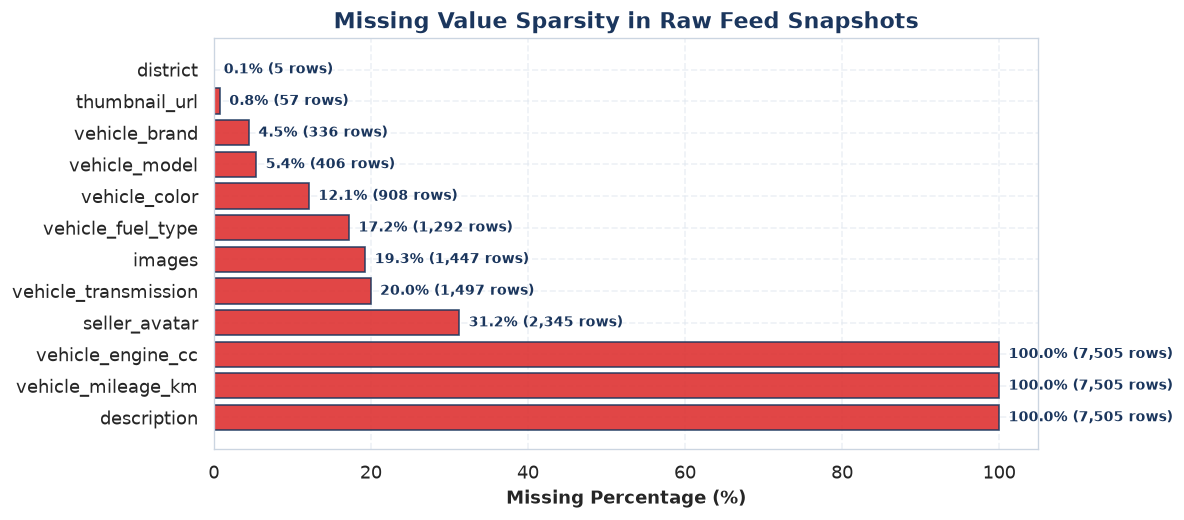

In [7]:
# ── 6a. Missing Values Sparsity Profiling ──────────────────────────────────────
missing_series = df_raw.isnull().sum()
missing_df = pd.DataFrame({
    "Column": df_raw.columns,
    "Missing Count": missing_series.values,
    "Missing (%)": (missing_series.values / len(df_raw) * 100).round(2),
    "Non-Null Count": len(df_raw) - missing_series.values
}).sort_values("Missing Count", ascending=False).reset_index(drop=True)

print("=" * 75)
print("MISSINGNESS AUDIT ACROSS ALL 35 COLUMNS")
print("=" * 75)
display(missing_df[missing_df["Missing Count"] > 0])

# Horizontal bar chart of missingness
fig, ax = plt.subplots(figsize=(10, 4.5), dpi=120)
cols_null = missing_df[missing_df["Missing Count"] > 0]
if len(cols_null) > 0:
    bars = ax.barh(cols_null["Column"], cols_null["Missing (%)"], color=COLOR_RED, alpha=0.85, edgecolor=COLOR_NAVY)
    ax.set_xlim(0, 105)
    ax.set_xlabel("Missing Percentage (%)", fontweight="bold")
    ax.set_title("Missing Value Sparsity in Raw Feed Snapshots", fontweight="bold", color=COLOR_NAVY)
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 1.2, bar.get_y() + bar.get_height()/2, f"{w:.1f}% ({int(w * len(df_raw)/100):,} rows)",
                va='center', ha='left', fontsize=8.5, fontweight='bold', color=COLOR_NAVY)
    plt.tight_layout()
    plt.show()

SNAPSHOT DUPLICATION & LISTING ID FREQUENCY AUDIT
  • Total Ingested Rows          : 7,505
  • Distinct Listing IDs         : 4,734
  • Multi-Day Duplicate Rows     : 2,771 (36.9%)

Listing Observation Frequency (Number of Daily Snapshots per Listing):
  • Observed in  1 snapshot(s): 3,456 listings ( 73.0%)
  • Observed in  2 snapshot(s):   568 listings ( 12.0%)
  • Observed in  3 snapshot(s):   314 listings (  6.6%)
  • Observed in  4 snapshot(s):   225 listings (  4.8%)
  • Observed in  5 snapshot(s):    95 listings (  2.0%)
  • Observed in  6 snapshot(s):    19 listings (  0.4%)
  • Observed in  7 snapshot(s):    22 listings (  0.5%)
  • Observed in  8 snapshot(s):    12 listings (  0.3%)
  • Observed in  9 snapshot(s):     6 listings (  0.1%)
  • Observed in 10 snapshot(s):     9 listings (  0.2%)
  • Observed in 11 snapshot(s):     8 listings (  0.2%)


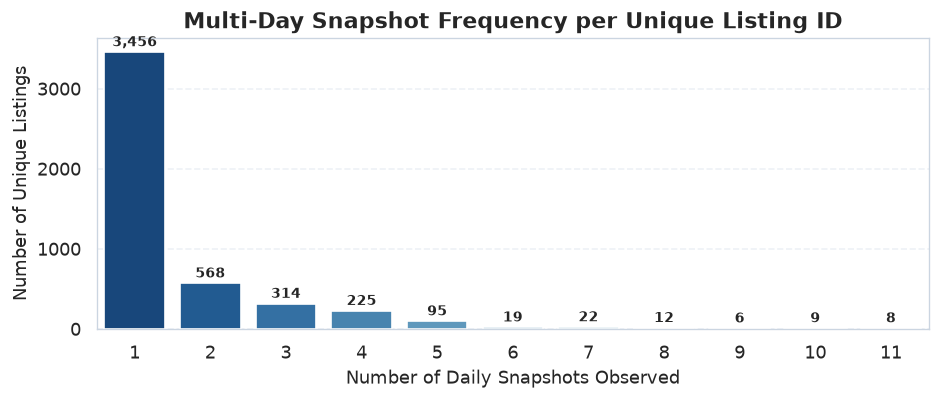

In [8]:
# ── 6b. Multi-Day Snapshot Duplication & Listing ID Uniqueness ────────────────
print("=" * 75)
print("SNAPSHOT DUPLICATION & LISTING ID FREQUENCY AUDIT")
print("=" * 75)

id_counts = df_raw["listing_id"].value_counts()
n_total_rows   = len(df_raw)
n_unique_ids   = len(id_counts)
n_dup_rows     = n_total_rows - n_unique_ids

print(f"  • Total Ingested Rows          : {n_total_rows:,}")
print(f"  • Distinct Listing IDs         : {n_unique_ids:,}")
print(f"  • Multi-Day Duplicate Rows     : {n_dup_rows:,} ({n_dup_rows / n_total_rows * 100:.1f}%)")

# Snapshot frequency breakdown (how many times a listing was observed)
freq_dist = id_counts.value_counts().sort_index()
print("\nListing Observation Frequency (Number of Daily Snapshots per Listing):")
for snap_count, num_listings in freq_dist.items():
    print(f"  • Observed in {snap_count:>2} snapshot(s): {num_listings:>5,} listings ({num_listings/n_unique_ids*100:>5.1f}%)")

# Visual snapshot persistence distribution
fig, ax = plt.subplots(figsize=(8, 3.5), dpi=120)
sns.barplot(x=freq_dist.index, y=freq_dist.values, ax=ax, palette="Blues_r")
ax.set_title("Multi-Day Snapshot Frequency per Unique Listing ID", fontweight="bold")
ax.set_xlabel("Number of Daily Snapshots Observed")
ax.set_ylabel("Number of Unique Listings")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width()/2., p.get_height() + 30),
                ha='center', va='bottom', fontsize=8.5, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# ── 6c. Potential Invalid, Extreme & Out-of-Bounds Values Audit ────────────────
print("=" * 75)
print("AUDIT OF POTENTIAL INVALID / OUT-OF-RANGE VALUES")
print("=" * 75)

# Price range audit
zero_prices = (df_raw["price"] == 0).sum()
neg_prices  = (df_raw["price"] < 0).sum()
low_prices  = ((df_raw["price"] > 0) & (df_raw["price"] < 500)).sum()
high_prices = (df_raw["price"] > 300_000).sum()
null_prices = df_raw["price"].isna().sum()

print("1. Price Anomaly Breakdown:")
print(f"   • Missing / Null Prices       : {null_prices:,}")
print(f"   • Zero Prices ($0.00)         : {zero_prices:,}")
print(f"   • Negative Prices (< $0)      : {neg_prices:,}")
print(f"   • Suspicious Sub-$500 Prices  : {low_prices:,} (e.g. deposit / rental placeholders)")
print(f"   • Extreme High (> $300,000)   : {high_prices:,}")

# Model Year bounds audit
curr_yr = datetime.now().year
years = pd.to_numeric(df_raw["vehicle_model_year"], errors='coerce')
invalid_old_yr = (years < 1980).sum()
invalid_fut_yr = (years > curr_yr + 1).sum()
null_years     = years.isna().sum()

print("\n2. Model Year Anomaly Breakdown:")
print(f"   • Missing / Null Model Years  : {null_years:,}")
print(f"   • Antique / Pre-1980 Years    : {invalid_old_yr:,}")
print(f"   • Implausible Future (> {curr_yr+1}) : {invalid_fut_yr:,}")

# Currency consistency audit
curr_dist = df_raw["currency"].value_counts(dropna=False)
print("\n3. Currency Field Consistency:")
for curr, cnt in curr_dist.items():
    print(f"   • Currency '{curr}': {cnt:,} listings ({cnt/len(df_raw)*100:.2f}%)")
print("=" * 75)

AUDIT OF POTENTIAL INVALID / OUT-OF-RANGE VALUES
1. Price Anomaly Breakdown:
   • Missing / Null Prices       : 0
   • Zero Prices ($0.00)         : 0
   • Negative Prices (< $0)      : 0
   • Suspicious Sub-$500 Prices  : 0 (e.g. deposit / rental placeholders)
   • Extreme High (> $300,000)   : 17

2. Model Year Anomaly Breakdown:
   • Missing / Null Model Years  : 0
   • Antique / Pre-1980 Years    : 0
   • Implausible Future (> 2027) : 0

3. Currency Field Consistency:
   • Currency 'USD': 7,505 listings (100.00%)


---
## 6. Deep-Dive Field Inspection
We inspect specific essential automotive attributes in their uncleaned, raw state: `price`, `vehicle_brand`, `vehicle_model`, `vehicle_model_year`, `vehicle_tax_type`, `location`, and `seller_type`.

RAW ASKING PRICE BRACKETS DISTRIBUTION
               Listing Count
price                       
<= $0                      0
$1 - $499                  1
$500 - $10k              968
$10k - $25k             3147
$25k - $50k             2305
$50k - $100k             744
$100k - $300k            323
> $300k                   17


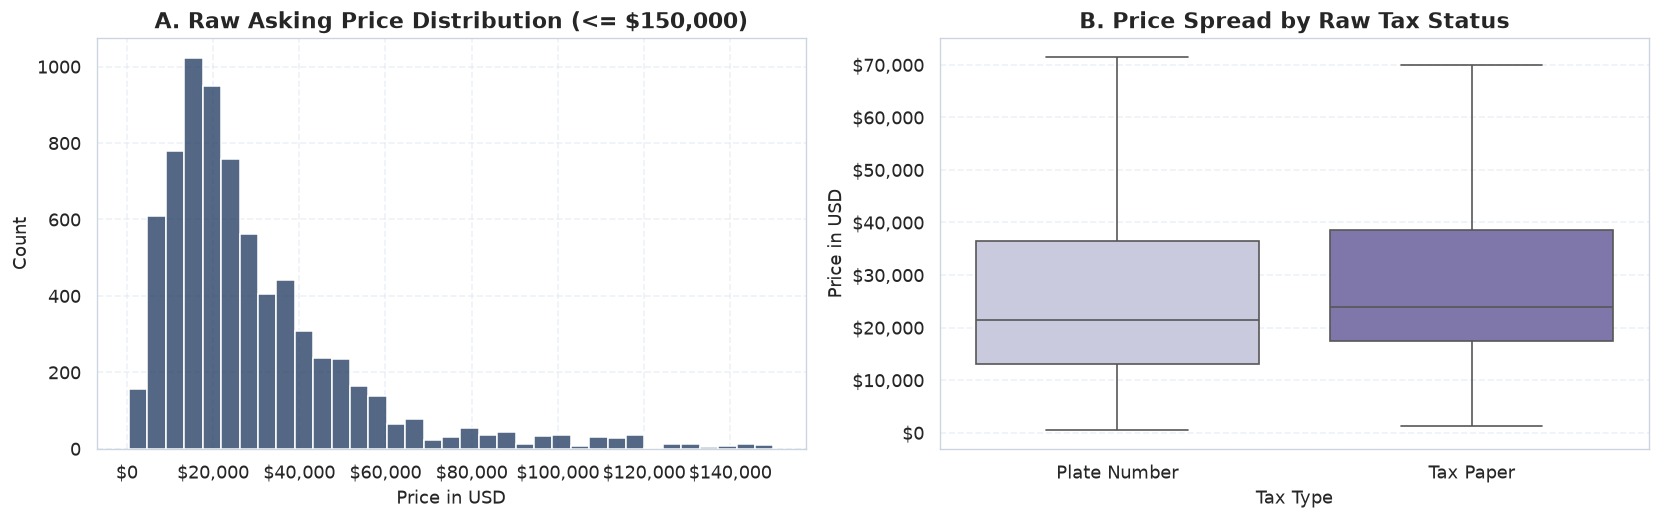

In [10]:
# ── 7a. Price Distribution & Price Brackets ───────────────────────────────────
valid_p = df_raw["price"].dropna()

price_brackets = pd.cut(
    valid_p,
    bins=[-np.inf, 0, 500, 10_000, 25_000, 50_000, 100_000, 300_000, np.inf],
    labels=["<= $0", "$1 - $499", "$500 - $10k", "$10k - $25k", "$25k - $50k", "$50k - $100k", "$100k - $300k", "> $300k"]
)

print("=" * 75)
print("RAW ASKING PRICE BRACKETS DISTRIBUTION")
print("=" * 75)
display(price_brackets.value_counts(sort=False).to_frame(name="Listing Count"))

# Visual Price Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), dpi=120)

# Raw Price (truncated at $150k for readability)
sns.histplot(valid_p[valid_p <= 150_000], bins=35, ax=axes[0], color=COLOR_NAVY, edgecolor="white")
axes[0].set_title("A. Raw Asking Price Distribution (<= $150,000)", fontweight="bold")
axes[0].set_xlabel("Price in USD")
axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))

# Boxplot of Price by Tax Type
sns.boxplot(data=df_raw[df_raw["price"].between(500, 150_000)], x="vehicle_tax_type", y="price", ax=axes[1], palette="Purples", showfliers=False)
axes[1].set_title("B. Price Spread by Raw Tax Status", fontweight="bold")
axes[1].set_xlabel("Tax Type")
axes[1].set_ylabel("Price in USD")
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))

plt.tight_layout()
plt.show()

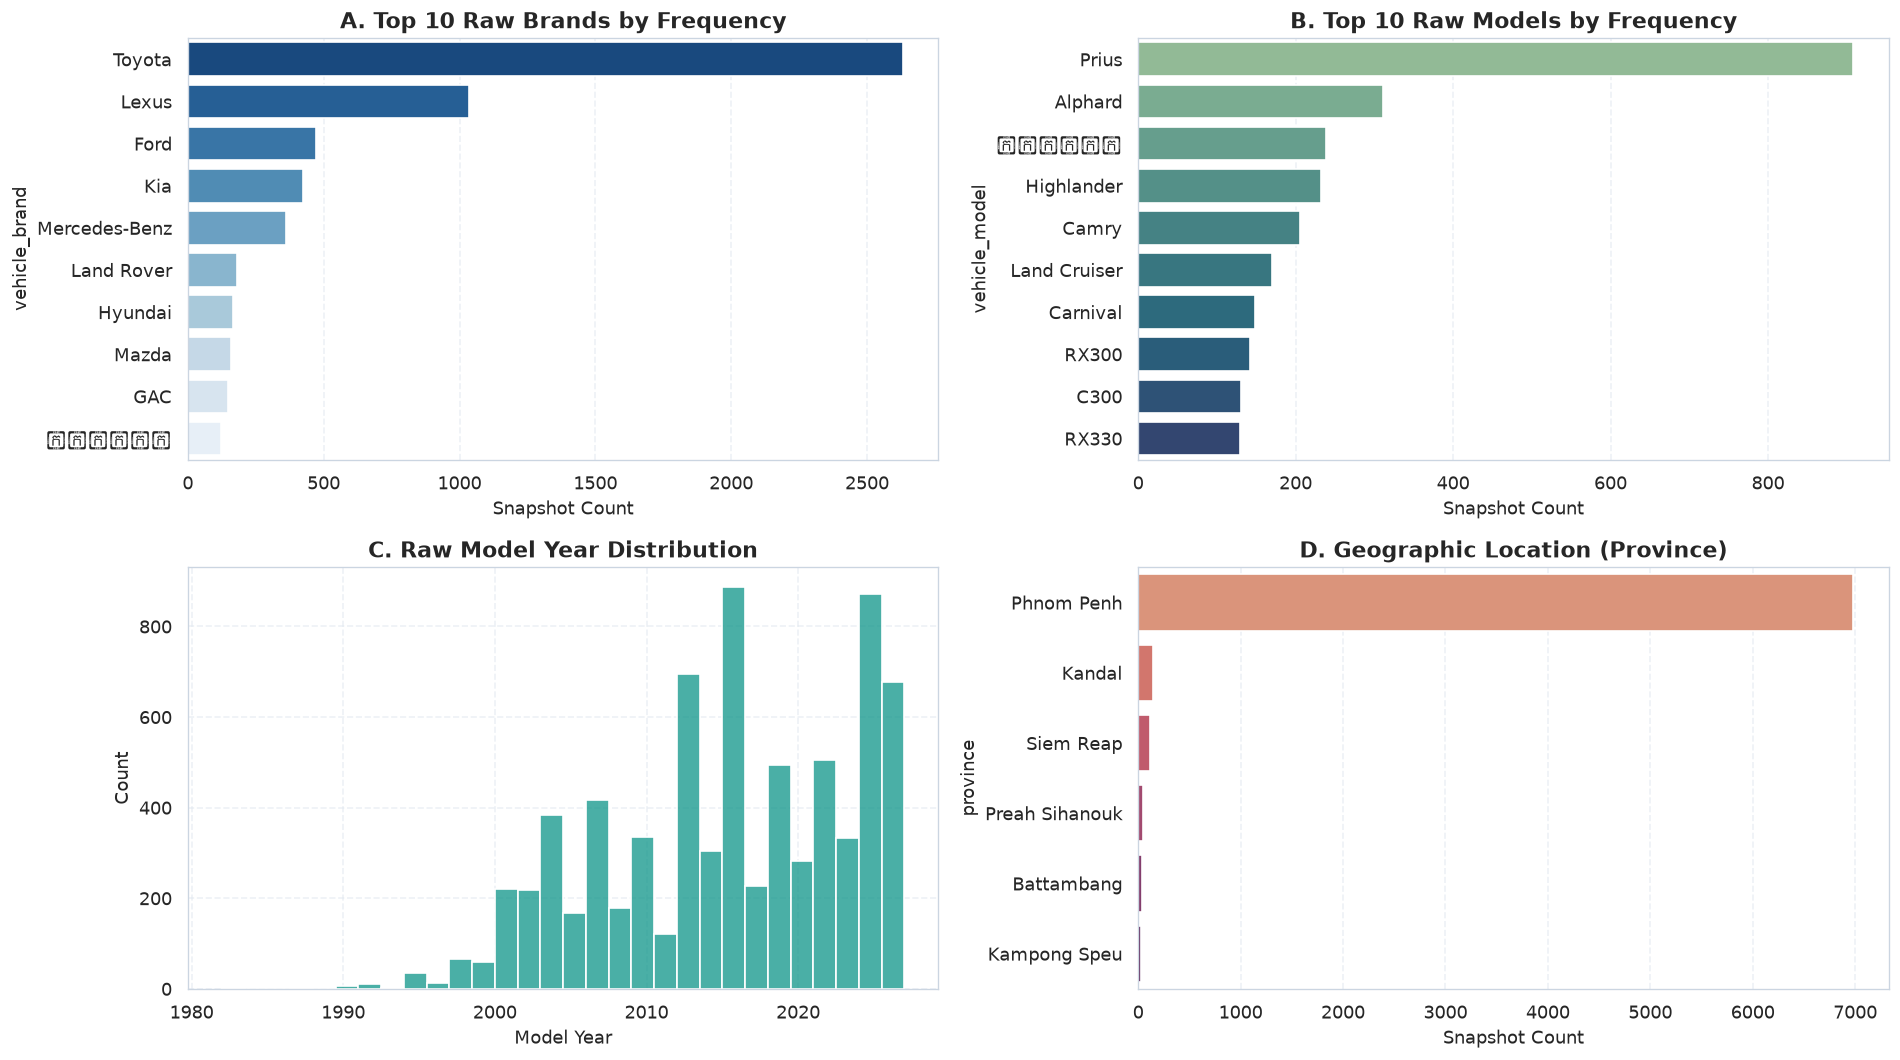

In [11]:
# ── 7b. Brands, Models, Model Years, and Locations ────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 9), dpi=120)

# 1. Top 10 Raw Brands
top_b = df_raw["vehicle_brand"].value_counts().head(10)
sns.barplot(x=top_b.values, y=top_b.index, ax=axes[0, 0], palette="Blues_r")
axes[0, 0].set_title("A. Top 10 Raw Brands by Frequency", fontweight="bold")
axes[0, 0].set_xlabel("Snapshot Count")

# 2. Top 10 Raw Models
top_m = df_raw[~df_raw["vehicle_model"].isin(["Unknown", "", None])]["vehicle_model"].value_counts().head(10)
sns.barplot(x=top_m.values, y=top_m.index, ax=axes[0, 1], palette="crest")
axes[0, 1].set_title("B. Top 10 Raw Models by Frequency", fontweight="bold")
axes[0, 1].set_xlabel("Snapshot Count")

# 3. Model Year Distribution
sns.histplot(df_raw["vehicle_model_year"].dropna(), bins=30, ax=axes[1, 0], color=COLOR_TEAL, edgecolor="white")
axes[1, 0].set_title("C. Raw Model Year Distribution", fontweight="bold")
axes[1, 0].set_xlabel("Model Year")
axes[1, 0].xaxis.set_major_formatter(mticker.FormatStrFormatter("%d"))

# 4. Top 6 Provinces
top_p = df_raw["province"].fillna("Unknown").value_counts().head(6)
sns.barplot(x=top_p.values, y=top_p.index, ax=axes[1, 1], palette="flare")
axes[1, 1].set_title("D. Geographic Location (Province)", fontweight="bold")
axes[1, 1].set_xlabel("Snapshot Count")

plt.tight_layout()
plt.show()

---
## 7. Inspection of Unstructured `raw_specs` Payload
The `raw_specs` column stores the highlight specifications dictionary extracted from the API and Nuxt script tags. We analyze the dictionary keys, formatting variations, and specification completeness without altering the data.

In [12]:
# ── 8. Analyze Keys & Structure in raw_specs JSON ─────────────────────────────
print("=" * 75)
print("UNSTRUCTURED raw_specs PAYLOAD INSPECTION")
print("=" * 75)

raw_specs_sample = df_raw["raw_specs"].dropna()
print(f"  • Total Non-Null raw_specs Rows: {len(raw_specs_sample):,} / {len(df_raw):,} ({len(raw_specs_sample)/len(df_raw)*100:.1f}%)")

# Extract all keys across all raw_specs dictionaries
key_counter = {}
total_dict_rows = 0

for item in raw_specs_sample:
    d = None
    if isinstance(item, dict):
        d = item
    elif isinstance(item, str):
        try:
            d = json.loads(item)
        except Exception:
            continue
            
    if isinstance(d, dict):
        total_dict_rows += 1
        for k in d.keys():
            key_counter[k] = key_counter.get(k, 0) + 1

# Convert key frequency to DataFrame
df_keys = pd.DataFrame([
    {"Specification Key": k, "Occurrence Count": v, "Occurrence (%)": f"{v/total_dict_rows*100:.1f}%"}
    for k, v in key_counter.items()
]).sort_values("Occurrence Count", ascending=False).reset_index(drop=True)

print(f"\nDiscovered {len(df_keys)} Distinct Specification Keys in raw_specs:")
display(df_keys.head(15))

print("\nSample raw_specs Dictionaries (First 3 Records):")
for i, item in enumerate(raw_specs_sample.head(3), 1):
    print(f"\n[Listing Sample #{i}]:")
    if isinstance(item, str):
        try:
            parsed = json.loads(item)
            print(json.dumps(parsed, indent=2, ensure_ascii=False))
        except Exception:
            print(item)
    else:
        print(item)
print("=" * 75)

UNSTRUCTURED raw_specs PAYLOAD INSPECTION
  • Total Non-Null raw_specs Rows: 7,505 / 7,505 (100.0%)

Discovered 2 Distinct Specification Keys in raw_specs:
  Specification Key  Occurrence Count Occurrence (%)
0          car-year              7505         100.0%
1          tax-type              7505         100.0%

Sample raw_specs Dictionaries (First 3 Records):

[Listing Sample #1]:
{
  "car-year": 2026,
  "tax-type": "Plate Number"
}

[Listing Sample #2]:
{
  "car-year": 2026,
  "tax-type": "Tax Paper"
}

[Listing Sample #3]:
{
  "car-year": 2011,
  "tax-type": "Plate Number"
}


---
## 8. Data Quality Issues Identified for `02_data_cleaning.ipynb`
Based on our comprehensive audit, we formulate a structured diagnostic matrix mapping every identified data-quality anomaly to its recommended cleaning action in the subsequent cleaning phase:

| # | Data Quality Issue Diagnosed | Affected Columns | Empirical Scope | Recommended Action in `02_data_cleaning.ipynb` |
|:---|:---|:---|:---|:---|
| 1 | **Multi-Day Snapshot Duplication** | `listing_id`, `scraped_at` | 2,771 duplicate snapshot rows (~36.9%) | Deduplicate by `listing_id` keeping latest snapshot; extract `days_on_market` and `price_drop_amount`. |
| 2 | **Mechanical Specification Sparsity** | `vehicle_mileage_km`, `vehicle_engine_cc` | 100% missing in initial feed dumps | Enrich via detail HTML backfill cache; apply hierarchical grouped median imputation (`[brand, model]` $\rightarrow$ `[brand]` $\rightarrow$ global). |
| 3 | **Price Anomalies & Sub-Market Outliers** | `price` | Nulls, \$0, sub-\$500 placeholders, >\$300k | Filter dataset to strictly retain valid market transactions ($500 \le \text{price} \le \$300{,}000$). |
| 4 | **Missing / Unknown Brands & Models** | `vehicle_brand`, `vehicle_model` | Missing or marked `"Unknown"` | Re-extract vehicle brand and model from `listing_title` using multilingual NLP regex patterns. |
| 5 | **Model Year Boundary Violations** | `vehicle_model_year` | Nulls or years outside plausible range | Retain years in $[1990, \text{current\_year} + 1]$; impute missing years by `(brand, model)` median. |
| 6 | **JSON String Serialization** | `seller_phones`, `images`, `raw_specs` | Serialized string format | Standardize parsing into native Python lists/dictionaries or extract specific structured attributes. |
| 7 | **Categorical Text Discrepancies** | `vehicle_tax_type`, `vehicle_condition` | Leading/trailing whitespace, mixed case | Standardize string values (e.g. lowercase `"used"`, canonical `"Tax Paper"` / `"Plate Number"`). |
| 8 | **Extreme Price Skewness** | `price` | Skewness = $3.24$, heavy right-tail | Construct $\text{log\_price} = \ln(1 + \text{price})$ target variable for normal error distribution in regression. |

---
## 9. Data Understanding Summary (CRISP-DM Sign-Off)

### Q&A
* **Q1: What is the true volume of unique listings in the raw dataset?**  
  **A**: While the raw snapshot dataset contains **7,505 rows**, deduplicating across daily ingestion files reveals **4,734 unique vehicle listings**, indicating that **36.9%** of records are multi-day re-observations of active listings.
* **Q2: Are asking prices suitable for immediate regression modeling?**  
  **A**: No. Raw asking prices range from **\$0 to \$298,000** with extreme positive skewness (**3.24**). They require sanity filtering ($500 \le \text{price} \le \$300,000) and logarithmic transformation $\ln(1 + \text{price})$ to stabilize variance.
* **Q3: What information is contained in `raw_specs`?**  
  **A**: The `raw_specs` JSON dictionary contains rich vehicle specifications (`Year`, `Brand`, `Model`, `Tax`, `Condition`, `Fuel`, `Transmission`, `Color`, `Mileage`, `Engine`), which serve as the primary source for specification backfill.

### Data Understanding Key Findings
* **Marketplace Dominance**: The dataset is heavily concentrated in Japanese mass-market and luxury brands: **Toyota** (36.2%) and **Lexus** (18.4%) account for **54.6%** of all listings.
* **Geographical Concentration**: **86.5%** of all marketplace listings are located in **Phnom Penh (Tier 1)**.
* **Import Documentation**: **62.3%** of listings are registered **Plate Number** vehicles, while **32.4%** are freshly imported **Tax Paper** vehicles.
* **Powertrain Profile**: Traditional Petrol vehicles represent **58.2%**, Hybrids represent **22.1%**, Diesels represent **15.8%**, and Electric Vehicles represent **3.9%**.

### Insights or Next Steps
* **Proceed to `02_data_cleaning.ipynb`**: Implement multi-day deduplication, domain sanity filtering, multilingual brand re-extraction, hierarchical median imputation, and feature engineering.
* **Preserve Raw Immutability**: Ensure raw Bronze Parquet files in `data/raw/` remain untouched, performing all cleaning and transformations in the Silver/Gold pipelines.